# Whitened Residual Outlier and Cluster Diagnostics

This notebook follows the whitened residual PCA notebook but focuses only on:

1. top absolute whitened residual locations;
2. whether those outliers cluster by time slot or by neighboring grid cells.

It keeps the GP/Vecchia model class unchanged. No robust or non-Gaussian likelihood is introduced.


In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')

import sys, time, contextlib, io, gc
import numpy as np
import pandas as pd
import torch
from torch.nn import Parameter
import matplotlib.pyplot as plt
from scipy import ndimage

sys.path.insert(0, '/Users/joonwonlee/Documents/GEMS_TCO-1/src')

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.vecchia_realdata_corridor_width_4x4_lag432 import (
    BLOCK_SHAPE,
    REFERENCE_ADVEC_LON_ABS,
    SPEC_NAME as VECCHIA_SPEC_NAME,
    build_model as build_corridor_width_432_model,
    model_spec as corridor_width_432_spec,
)

pd.set_option('display.max_columns', 160)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 180

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())


torch: 2.5.1
cuda available: False


In [2]:
YEAR = '2024'
MONTH = 7
DAYS_LIST = [13]
DAY_IDX = DAYS_LIST[0]
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
LAT_LON_RESOLUTION = [1, 1]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.double
SMOOTH = 0.5
DAILY_STRIDE = 2
TARGET_CHUNK_SIZE = 96

REFERENCE_ADVEC_LON_ABS = 0.126
MODEL_SPEC = corridor_width_432_spec(REFERENCE_ADVEC_LON_ABS)

OUT_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/space_time/vecchia_cluster_batch/diagnostics')
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'whitened_outlier_cluster_corridor_20240714_lag432'
RAW_DIAG_PREFIX = 'pca_detrend_corridor_20240714_lag432'
CACHED_FIT_SUMMARY = OUT_DIR / f'{RAW_DIAG_PREFIX}_fit_summary.csv'

DESIGNS = ['hour_lat', 'hour_latlon', 'hour_quadratic', 'hour_spatial']
FOCUS_DESIGN = 'hour_lat'
OUTLIER_Q = 0.999
TOP_N_ROWS = 80
ROUND_DECIMALS = 4

INIT_PHYSICAL = {
    'sigmasq': 10.0,
    'range_lat': 0.30,
    'range_lon': 0.40,
    'range_time': 2.0,
    'advec_lat': 0.05,
    'advec_lon': -0.10,
    'nugget': 2.5,
}

print('device:', DEVICE)
print('spec:', VECCHIA_SPEC_NAME)
print('model spec:', MODEL_SPEC)
print('cached fit summary exists:', CACHED_FIT_SUMMARY.exists())


device: cpu
spec: corridor_width_4x4_lag432_delta0p126
model spec: {'spec_name': 'corridor_width_4x4_lag432_delta0p126', 'strategy': 'offset_corridor_tapered', 'conditioning_mode': 'corridor_width_light', 'block_shape': (4, 4), 'lag_counts': (4, 3, 2), 'lag_pattern': '4/3/2', 'reference_advec_lon_abs': 0.126, 'lag1_lon_offset': 0.126, 'lag2_lon_offset': 0.252, 'lag1_lon_interval': (0.063, 0.189), 'lag2_lon_interval': (0.0, 0.252), 'corridor_anchor_mode': 'width'}
cached fit summary exists: True


In [3]:
def round_numeric_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def physical_to_log_phi(params):
    sigmasq = float(params['sigmasq'])
    range_lat = float(params['range_lat'])
    range_lon = float(params['range_lon'])
    range_time = float(params['range_time'])
    nugget = float(params['nugget'])
    phi2 = 1.0 / range_lon
    phi1 = sigmasq * phi2
    phi3 = (range_lon / range_lat) ** 2
    phi4 = (range_lon / range_time) ** 2
    return [
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        float(params['advec_lat']), float(params['advec_lon']), np.log(nugget),
    ]


def fitted_params_from_summary(path):
    df = pd.read_csv(path)
    row = df.iloc[0]
    physical = {
        'sigmasq': row['est_sigmasq'],
        'range_lat': row['est_range_lat'],
        'range_lon': row['est_range_lon'],
        'range_time': row['est_range_time'],
        'advec_lat': row['est_advec_lat'],
        'advec_lon': row['est_advec_lon'],
        'nugget': row['est_nugget'],
    }
    raw = physical_to_log_phi(physical)
    return torch.tensor(raw, dtype=torch.float64, device=DEVICE), physical


if not CACHED_FIT_SUMMARY.exists():
    raise FileNotFoundError(f'Missing cached fit summary: {CACHED_FIT_SUMMARY}. Run the raw or whitened PCA diagnostic first.')

fitted_params, fitted_physical = fitted_params_from_summary(CACHED_FIT_SUMMARY)
print(fitted_physical)


{'sigmasq': 7.780827273909126, 'range_lat': 0.2298598920210472, 'range_lon': 0.2808629520986649, 'range_time': 1.4182986839217735, 'advec_lat': 0.0046574760937557, 'advec_lon': -0.0375118646225009, 'nugget': 1.122391777010093}


## Load data and precompute model batches

In [4]:
data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

df_map, _, _, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=LAT_LON_RESOLUTION,
    mm_cond_number=1,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)

key_idx = sorted(df_map)
base_grid_coords_np = df_map[key_idx[0]][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
print('n hourly slots:', len(key_idx))
print('monthly_mean:', monthly_mean)
print('grid:', base_grid_coords_np.shape, 'unique lat/lon:', len(np.unique(base_grid_coords_np[:,0])), len(np.unique(base_grid_coords_np[:,1])))


--- Global Monthly Mean for 2024-7: 257.9726 ---
n hourly slots: 248
monthly_mean: 257.9726104252314
grid: (18126, 2) unique lat/lon: 114 159


In [5]:
def assert_grid_order_consistent(keys, base_coords):
    for k in keys:
        coords = df_map[k][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
        if coords.shape != base_coords.shape or not np.allclose(coords, base_coords, equal_nan=True):
            raise RuntimeError(f'Grid coordinate order differs at {k}; cluster local-index mapping is not reusable.')

hour_indices = [DAY_IDX * 8, (DAY_IDX + 1) * 8]
selected_keys = key_idx[hour_indices[0]:hour_indices[1]]
assert_grid_order_consistent(selected_keys, base_grid_coords_np)
print(selected_keys)


['2024_07_y24m07day14_hm00:53', '2024_07_y24m07day14_hm01:53', '2024_07_y24m07day14_hm02:53', '2024_07_y24m07day14_hm03:53', '2024_07_y24m07day14_hm04:48', '2024_07_y24m07day14_hm05:48', '2024_07_y24m07day14_hm06:48', '2024_07_y24m07day14_hm07:48']


In [6]:
day_hourly_map, _ = data_load_instance.load_working_data(
    df_map,
    monthly_mean,
    hour_indices,
    ord_mm=None,
    dtype=DTYPE,
    keep_ori=True,
)
day_map = {k: v.to(DEVICE) for k, v in day_hourly_map.items()}
n_time = len(day_map)
n_grid = int(next(iter(day_map.values())).shape[0])

model = build_corridor_width_432_model(
    smooth=SMOOTH,
    input_map=day_map,
    grid_coords=base_grid_coords_np,
    reference_advec_lon_abs=REFERENCE_ADVEC_LON_ABS,
    daily_stride=DAILY_STRIDE,
    target_chunk_size=TARGET_CHUNK_SIZE,
)

t0 = time.time()
model.precompute_conditioning_sets()
print('precompute_s:', round(time.time() - t0, 3))
print(model.cluster_summary())


Pre-computing StrategyClusterVecchia (smooth=0.5, strategy=offset_corridor_tapered, block=(4, 4), origin=0/0, lag_blocks=4/3/2, basis=corridor, force_center=0, offsets=0.1260/0.2520, corridors=(0.063, 0.189)/(0.0, 0.252), anchor_mode=width)... 

Done. clusters=1160, max_points/block=16, target_blocks=9278, target_points=144078, batches=[A:m64:b6x1, A:m64:b8x53, A:m64:b11x2, A:m64:b12x12, A:m64:b16x1092, AB:m112:b2x1, AB:m112:b7x1, AB:m112:b8x50, AB:m112:b11x2, AB:m112:b12x14, ... (26 batches)]
precompute_s: 0.957
{'n_clusters': 1160, 'block_shape_lat': 4, 'block_shape_lon': 4, 'max_points_per_cluster': 16, 'n_target_blocks': 9278, 'n_target_points': 144078, 'n_batches': 26, 'target_chunk_size': 96, 'strategy': 'offset_corridor_tapered', 'temporal_basis': 'corridor', 'force_target_center': 0, 'lag0_block_count': 4, 'lag1_block_count': 3, 'lag2_block_count': 2, 'lag1_max_blocks': 3, 'lag2_max_blocks': 2, 'lag1_lon_offset': 0.126, 'lag2_lon_offset': 0.252, 'lag1_lon_interval_lo': 0.063, 'lag1_lon_interval_hi': 0.189, 'lag2_lon_interval_lo': 0.0, 'lag2_lon_interval_hi': 0.252, 'corridor_anchor_mode': 'width', 'grid_lon_step': 0.06300000000000239, 'corridor_block_lon_width': 0.25200000000000955, 'block_row_offset': 0, 'block_col_of

## Reconstruct whitened residual matrices

In [7]:
def observed_coord_means(day_map):
    rows = torch.cat([v.detach().cpu() for v in day_map.values()], dim=0).numpy()
    ok = np.isfinite(rows[:, 2]) & np.isfinite(rows[:, 0]) & np.isfinite(rows[:, 1])
    return float(rows[ok, 0].mean()), float(rows[ok, 1].mean())

lat_mean_data, lon_mean_data = observed_coord_means(day_map)
print('model.lat_mean_val:', float(model.lat_mean_val))
print('data lat/lon mean:', lat_mean_data, lon_mean_data)


def feature_names(design):
    dummies = [f'D{k}' for k in range(1, 8)]
    if design == 'hour_lat':
        return ['intercept', 'lat_c'] + dummies
    if design == 'hour_latlon':
        return ['intercept', 'lat_c', 'lon_c'] + dummies
    if design == 'hour_quadratic':
        return ['intercept', 'lat_c', 'lon_c', 'lat_c2', 'lat_lon_c', 'lon_c2'] + dummies
    if design == 'hour_spatial':
        hours = [f'H{k}' for k in range(8)]
        return hours + [f'{h}:lat_c' for h in hours] + [f'{h}:lon_c' for h in hours]
    raise ValueError(design)


def _pad_dummies(dums):
    width = dums.shape[-1]
    if width >= 7:
        return dums[..., :7]
    pad = torch.zeros((*dums.shape[:-1], 7 - width), device=dums.device, dtype=dums.dtype)
    return torch.cat([dums, pad], dim=-1)


def design_from_batch(model, batch, design, lon_mean):
    coords = batch.X.to(torch.float64)
    lat = coords[..., 0:1] - float(model.lat_mean_val)
    lon = coords[..., 1:2] - float(lon_mean)
    ones = torch.ones_like(lat)
    dums = _pad_dummies(batch.Locs[..., 2:9].to(torch.float64))

    if design == 'hour_lat':
        X = torch.cat([ones, lat, dums], dim=-1)
    elif design == 'hour_latlon':
        X = torch.cat([ones, lat, lon, dums], dim=-1)
    elif design == 'hour_quadratic':
        X = torch.cat([ones, lat, lon, lat.pow(2), lat * lon, lon.pow(2), dums], dim=-1)
    elif design == 'hour_spatial':
        first_hour = (1.0 - dums.sum(dim=-1, keepdim=True)).clamp(min=0.0, max=1.0)
        hour_onehot = torch.cat([first_hour, dums], dim=-1)
        X = torch.cat([hour_onehot, hour_onehot * lat, hour_onehot * lon], dim=-1)
    else:
        raise ValueError(design)
    return X.masked_fill(batch.is_dummy, 0.0).contiguous()


def gls_beta_for_design(model, params, design, lon_mean, jitter=1e-6):
    p = len(feature_names(design))
    xt_sinv_x = torch.zeros((p, p), device=model.device, dtype=torch.float64)
    xt_sinv_y = torch.zeros((p, 1), device=model.device, dtype=torch.float64)
    y_sinv_y = torch.tensor(0.0, device=model.device, dtype=torch.float64)
    log_det = torch.tensor(0.0, device=model.device, dtype=torch.float64)
    total_n = 0
    chunk_size = max(1, int(model.target_chunk_size))
    with torch.no_grad():
        for batch in model._cluster_batches:
            if batch.X.shape[0] == 0:
                continue
            locs_all = design_from_batch(model, batch, design, lon_mean)
            target_slice = slice(batch.max_cond_points, batch.max_cond_points + batch.target_size)
            for start in range(0, batch.X.shape[0], chunk_size):
                end = min(start + chunk_size, batch.X.shape[0])
                cov_chunk = model.matern_cov_batched(params, batch.X[start:end])
                L_chunk = torch.linalg.cholesky(cov_chunk)
                z_locs = torch.linalg.solve_triangular(L_chunk, locs_all[start:end], upper=False)
                z_y = torch.linalg.solve_triangular(L_chunk, batch.Y[start:end], upper=False)
                u_x = z_locs[:, target_slice, :].reshape(-1, p)
                u_y = z_y[:, target_slice, :].reshape(-1, 1)
                diag_l = torch.diagonal(L_chunk, dim1=1, dim2=2)[:, target_slice]
                xt_sinv_x += u_x.T @ u_x
                xt_sinv_y += u_x.T @ u_y
                y_sinv_y += (u_y.T @ u_y).squeeze()
                log_det += 2.0 * torch.sum(torch.log(diag_l))
                total_n += int(u_y.shape[0])
        beta = torch.linalg.solve(xt_sinv_x + torch.eye(p, device=model.device, dtype=torch.float64) * jitter, xt_sinv_y)
        quad = y_sinv_y - 2.0 * (beta.T @ xt_sinv_y).squeeze() + (beta.T @ xt_sinv_x @ beta).squeeze()
        nll = 0.5 * (log_det + quad) / max(total_n, 1)
    return beta, float(nll.detach().cpu().item()), int(total_n)


def whitened_residual_matrix_for_design(model, params, design, beta, lon_mean, n_time, n_grid):
    W = np.full((n_time, n_grid), np.nan, dtype=np.float64)
    chunk_size = max(1, int(model.target_chunk_size))
    with torch.no_grad():
        for batch in model._cluster_batches:
            if batch.X.shape[0] == 0:
                continue
            locs_all = design_from_batch(model, batch, design, lon_mean)
            target_slice = slice(batch.max_cond_points, batch.max_cond_points + batch.target_size)
            for start in range(0, batch.X.shape[0], chunk_size):
                end = min(start + chunk_size, batch.X.shape[0])
                cov_chunk = model.matern_cov_batched(params, batch.X[start:end])
                L_chunk = torch.linalg.cholesky(cov_chunk)
                z_locs = torch.linalg.solve_triangular(L_chunk, locs_all[start:end], upper=False)
                z_y = torch.linalg.solve_triangular(L_chunk, batch.Y[start:end], upper=False)
                pred = torch.matmul(z_locs[:, target_slice, :], beta).squeeze(-1)
                resid = (z_y[:, target_slice, 0] - pred).detach().cpu().numpy()
                target_global = batch.T[start:end, target_slice].detach().cpu().numpy()
                flat_idx = target_global.reshape(-1)
                flat_resid = resid.reshape(-1)
                real_ok = flat_idx < (n_time * n_grid)
                time_idx = flat_idx[real_ok] // n_grid
                point_idx = flat_idx[real_ok] % n_grid
                W[time_idx, point_idx] = flat_resid[real_ok]
    return W


model.lat_mean_val: -0.4802863299846649
data lat/lon mean: -0.4802863451661079 126.0133083267258


In [8]:
whitened = {}
summary_rows = []
for design in DESIGNS:
    print('computing', design)
    beta, fixed_cov_nll, total_n = gls_beta_for_design(model, fitted_params, design, lon_mean_data)
    W = whitened_residual_matrix_for_design(model, fitted_params, design, beta, lon_mean_data, n_time, n_grid)
    absw = np.abs(W[np.isfinite(W)])
    threshold = float(np.quantile(absw, OUTLIER_Q))
    n_out = int(np.sum(np.abs(W) >= threshold))
    whitened[design] = {'W': W, 'threshold': threshold, 'beta': beta.detach().cpu().numpy().reshape(-1)}
    summary_rows.append({
        'design': design,
        'fixed_cov_nll': fixed_cov_nll,
        'total_n': total_n,
        'threshold_q': OUTLIER_Q,
        'abs_threshold': threshold,
        'n_outliers': n_out,
        'outlier_rate': n_out / np.isfinite(W).sum(),
        'max_abs': float(np.nanmax(np.abs(W))),
        'mean': float(np.nanmean(W)),
        'sd': float(np.nanstd(W)),
        'skew': float(pd.Series(W[np.isfinite(W)]).skew()),
        'kurtosis': float(pd.Series(W[np.isfinite(W)]).kurt()),
    })

summary_df = pd.DataFrame(summary_rows)
display(round_numeric_df(summary_df))
summary_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_design_outlier_summary.csv', index=False)

np.savez_compressed(
    OUT_DIR / f'{OUT_PREFIX}_whitened_matrices.npz',
    **{f'{d}_W': whitened[d]['W'] for d in DESIGNS},
    **{f'{d}_threshold': np.array([whitened[d]['threshold']]) for d in DESIGNS},
)


computing hour_lat


computing hour_latlon


computing hour_quadratic


computing hour_spatial


,design,fixed_cov_nll,total_n,threshold_q,abs_threshold,n_outliers,outlier_rate,max_abs,mean,sd,skew,kurtosis
0,hour_lat,1.0696,144078,0.999,5.2779,145,0.001,77.6565,-0.0048,1.0000,4.0495,270.5980
1,hour_latlon,1.0694,144078,0.999,5.2825,145,0.001,77.6558,-0.0046,0.9998,4.0618,270.8579
2,hour_quadratic,1.0691,144078,0.999,5.2886,145,0.001,77.6570,-0.0042,0.9994,4.0648,271.2377
3,hour_spatial,1.0691,144078,0.999,5.2819,145,0.001,77.6509,-0.0046,0.9994,4.0709,271.1581


## Focus-design top outliers

In [9]:
unique_lats = np.sort(np.unique(base_grid_coords_np[:, 0]))
unique_lons = np.sort(np.unique(base_grid_coords_np[:, 1]))
lat_to_row = {round(float(v), 10): i for i, v in enumerate(unique_lats)}
lon_to_col = {round(float(v), 10): i for i, v in enumerate(unique_lons)}
point_row = np.array([lat_to_row[round(float(v), 10)] for v in base_grid_coords_np[:, 0]], dtype=int)
point_col = np.array([lon_to_col[round(float(v), 10)] for v in base_grid_coords_np[:, 1]], dtype=int)
grid_shape = (len(unique_lats), len(unique_lons))
print('grid_shape:', grid_shape, 'n_grid:', n_grid)

W_focus = whitened[FOCUS_DESIGN]['W']
thr_focus = whitened[FOCUS_DESIGN]['threshold']
abs_focus = np.abs(W_focus)
out_mask = abs_focus >= thr_focus

records = []
for t_idx, key in enumerate(selected_keys):
    rows_t = day_map[key].detach().cpu().numpy()
    idxs = np.where(out_mask[t_idx])[0]
    for j in idxs:
        records.append({
            'design': FOCUS_DESIGN,
            'time_idx': t_idx,
            'time_key': key,
            'point_idx': int(j),
            'grid_row': int(point_row[j]),
            'grid_col': int(point_col[j]),
            'grid_lat': float(base_grid_coords_np[j, 0]),
            'grid_lon': float(base_grid_coords_np[j, 1]),
            'source_lat': float(rows_t[j, 0]),
            'source_lon': float(rows_t[j, 1]),
            'centered_o3': float(rows_t[j, 2]),
            'whitened_resid': float(W_focus[t_idx, j]),
            'abs_whitened_resid': float(abs_focus[t_idx, j]),
            'sign': int(np.sign(W_focus[t_idx, j])),
        })

outlier_df = pd.DataFrame(records).sort_values('abs_whitened_resid', ascending=False).reset_index(drop=True)
hour_counts = outlier_df.groupby(['time_idx', 'time_key']).agg(
    n_outliers=('point_idx', 'size'),
    max_abs=('abs_whitened_resid', 'max'),
    mean_abs=('abs_whitened_resid', 'mean'),
    n_positive=('sign', lambda s: int((s > 0).sum())),
    n_negative=('sign', lambda s: int((s < 0).sum())),
).reset_index()

display(round_numeric_df(hour_counts))
display(round_numeric_df(outlier_df.head(TOP_N_ROWS)))

outlier_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_top_q{OUTLIER_Q}_outliers.csv', index=False)
hour_counts.to_csv(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_hour_counts.csv', index=False)


grid_shape: (114, 159) n_grid: 18126


,time_idx,time_key,n_outliers,max_abs,mean_abs,n_positive,n_negative
0,0,2024_07_y24m07day14_hm00:53,19,32.7598,8.8607,15,4
1,1,2024_07_y24m07day14_hm01:53,22,15.1705,6.4292,21,1
2,2,2024_07_y24m07day14_hm02:53,22,21.9875,7.0894,18,4
3,3,2024_07_y24m07day14_hm03:53,29,24.3442,6.7964,23,6
4,4,2024_07_y24m07day14_hm04:48,17,7.5693,5.9294,14,3
5,5,2024_07_y24m07day14_hm05:48,8,6.6659,5.9204,7,1
6,6,2024_07_y24m07day14_hm06:48,19,7.4877,5.8846,18,1
7,7,2024_07_y24m07day14_hm07:48,9,77.6565,16.9808,3,6


,design,time_idx,time_key,point_idx,grid_row,grid_col,grid_lat,grid_lon,source_lat,source_lon,centered_o3,whitened_resid,abs_whitened_resid,sign
0,hour_lat,7,2024_07_y24m07day14_hm07:48,15960,13,98,-2.400,127.220,-2.4096,127.1665,131.5287,77.6565,77.6565,1
1,hour_lat,0,2024_07_y24m07day14_hm00:53,17208,5,122,-2.752,128.732,-2.7502,128.7504,49.7101,32.7598,32.7598,1
2,hour_lat,3,2024_07_y24m07day14_hm03:53,12401,36,0,-1.388,121.046,-1.3936,121.0154,44.5127,24.3442,24.3442,1
3,hour_lat,2,2024_07_y24m07day14_hm02:53,12557,35,3,-1.432,121.235,-1.4528,121.2043,34.5516,21.9875,21.9875,1
4,hour_lat,0,2024_07_y24m07day14_hm00:53,11272,43,16,-1.080,122.054,-1.0888,122.0397,32.2394,18.1175,18.1175,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,hour_lat,2,2024_07_y24m07day14_hm02:53,5357,80,48,0.548,124.070,0.5405,124.0481,8.1102,5.8575,5.8575,1
76,hour_lat,3,2024_07_y24m07day14_hm03:53,4290,87,2,0.856,121.172,0.8654,121.1677,10.7461,5.8483,5.8483,1
77,hour_lat,6,2024_07_y24m07day14_hm06:48,15896,14,3,-2.356,121.235,-2.3616,121.1778,11.1486,5.8445,5.8445,1
78,hour_lat,1,2024_07_y24m07day14_hm01:53,7279,68,34,0.020,123.188,0.0265,123.1792,8.5129,5.8437,5.8437,1


## Connected spatial clusters of top outliers

In [10]:
structure = np.ones((3, 3), dtype=int)
cluster_records = []
for t_idx, key in enumerate(selected_keys):
    grid_mask = np.zeros(grid_shape, dtype=bool)
    idxs = np.where(out_mask[t_idx])[0]
    grid_mask[point_row[idxs], point_col[idxs]] = True
    labels, n_lab = ndimage.label(grid_mask, structure=structure)
    for lab in range(1, n_lab + 1):
        rr, cc = np.where(labels == lab)
        point_candidates = []
        for r, c in zip(rr, cc):
            point_candidates.extend(np.where((point_row == r) & (point_col == c))[0].tolist())
        point_candidates = np.array(point_candidates, dtype=int)
        vals = W_focus[t_idx, point_candidates]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        cluster_records.append({
            'design': FOCUS_DESIGN,
            'time_idx': t_idx,
            'time_key': key,
            'cluster_id': lab,
            'cluster_size': int(len(rr)),
            'max_abs': float(np.nanmax(np.abs(vals))),
            'mean_abs': float(np.nanmean(np.abs(vals))),
            'mean_signed': float(np.nanmean(vals)),
            'n_positive': int(np.sum(vals > 0)),
            'n_negative': int(np.sum(vals < 0)),
            'lat_min': float(unique_lats[rr.min()]),
            'lat_max': float(unique_lats[rr.max()]),
            'lon_min': float(unique_lons[cc.min()]),
            'lon_max': float(unique_lons[cc.max()]),
            'row_min': int(rr.min()),
            'row_max': int(rr.max()),
            'col_min': int(cc.min()),
            'col_max': int(cc.max()),
        })

cluster_df = pd.DataFrame(cluster_records)
if cluster_df.empty:
    print('No connected clusters found at threshold.')
else:
    cluster_df = cluster_df.sort_values(['cluster_size', 'max_abs'], ascending=False).reset_index(drop=True)
    cluster_hour_summary = cluster_df.groupby(['time_idx', 'time_key']).agg(
        n_clusters=('cluster_id', 'size'),
        largest_cluster=('cluster_size', 'max'),
        clusters_ge3=('cluster_size', lambda s: int((s >= 3).sum())),
        clusters_ge5=('cluster_size', lambda s: int((s >= 5).sum())),
        max_abs=('max_abs', 'max'),
    ).reset_index()
    display(round_numeric_df(cluster_hour_summary))
    display(round_numeric_df(cluster_df.head(40)))
    cluster_hour_summary.to_csv(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_cluster_hour_summary.csv', index=False)
    cluster_df.to_csv(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_clusters.csv', index=False)


,time_idx,time_key,n_clusters,largest_cluster,clusters_ge3,clusters_ge5,max_abs
0,0,2024_07_y24m07day14_hm00:53,13,4,2,0,32.7598
1,1,2024_07_y24m07day14_hm01:53,21,2,0,0,15.1705
2,2,2024_07_y24m07day14_hm02:53,21,2,0,0,21.9875
3,3,2024_07_y24m07day14_hm03:53,24,4,1,0,24.3442
4,4,2024_07_y24m07day14_hm04:48,16,2,0,0,7.5693
5,5,2024_07_y24m07day14_hm05:48,8,1,0,0,6.6659
6,6,2024_07_y24m07day14_hm06:48,17,2,0,0,7.4877
7,7,2024_07_y24m07day14_hm07:48,5,5,1,1,77.6565


,design,time_idx,time_key,cluster_id,cluster_size,max_abs,mean_abs,mean_signed,n_positive,n_negative,lat_min,lat_max,lon_min,lon_max,row_min,row_max,col_min,col_max
0,hour_lat,7,2024_07_y24m07day14_hm07:48,1,5,77.6565,25.4241,5.6385,1,4,-2.444,-2.400,127.157,127.283,12,13,97,99
1,hour_lat,3,2024_07_y24m07day14_hm03:53,5,4,24.3442,11.7058,3.3108,2,2,-1.432,-1.344,121.046,121.109,35,37,0,1
2,hour_lat,0,2024_07_y24m07day14_hm00:53,9,4,18.1175,12.3540,5.3388,2,2,-1.168,-1.080,121.991,122.054,41,43,15,16
3,hour_lat,0,2024_07_y24m07day14_hm00:53,1,3,32.7598,16.0196,5.8203,1,2,-2.796,-2.752,128.669,128.732,4,5,121,122
4,hour_lat,2,2024_07_y24m07day14_hm02:53,4,2,21.9875,17.2141,4.7734,1,1,-1.476,-1.432,121.235,121.235,34,35,3,3
5,hour_lat,1,2024_07_y24m07day14_hm01:53,21,2,15.1705,10.2447,4.9258,1,1,1.780,1.824,124.889,124.889,108,109,61,61
6,hour_lat,4,2024_07_y24m07day14_hm04:48,3,2,7.5693,6.6642,6.6642,2,0,-1.256,-1.256,121.487,121.550,39,39,7,8
7,hour_lat,3,2024_07_y24m07day14_hm03:53,7,2,6.9801,6.1622,6.1622,2,0,-1.256,-1.256,121.487,121.550,39,39,7,8
8,hour_lat,3,2024_07_y24m07day14_hm03:53,3,2,6.0862,5.9262,-0.1600,1,1,-1.740,-1.696,124.763,124.763,28,29,59,59
9,hour_lat,0,2024_07_y24m07day14_hm00:53,8,2,6.0723,5.8994,5.8994,2,0,-1.300,-1.300,126.086,126.149,38,38,80,81


## Plots

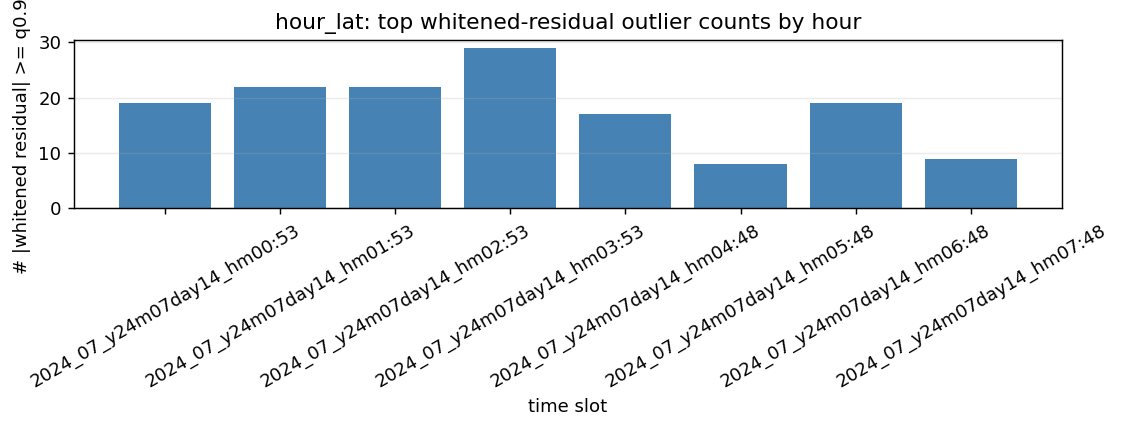

In [11]:
fig, ax = plt.subplots(figsize=(8.8, 3.4))
ax.bar(hour_counts['time_key'], hour_counts['n_outliers'], color='steelblue')
ax.set_ylabel(f'# |whitened residual| >= q{OUTLIER_Q}')
ax.set_xlabel('time slot')
ax.set_title(f'{FOCUS_DESIGN}: top whitened-residual outlier counts by hour')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_hour_outlier_counts.png')
plt.show()


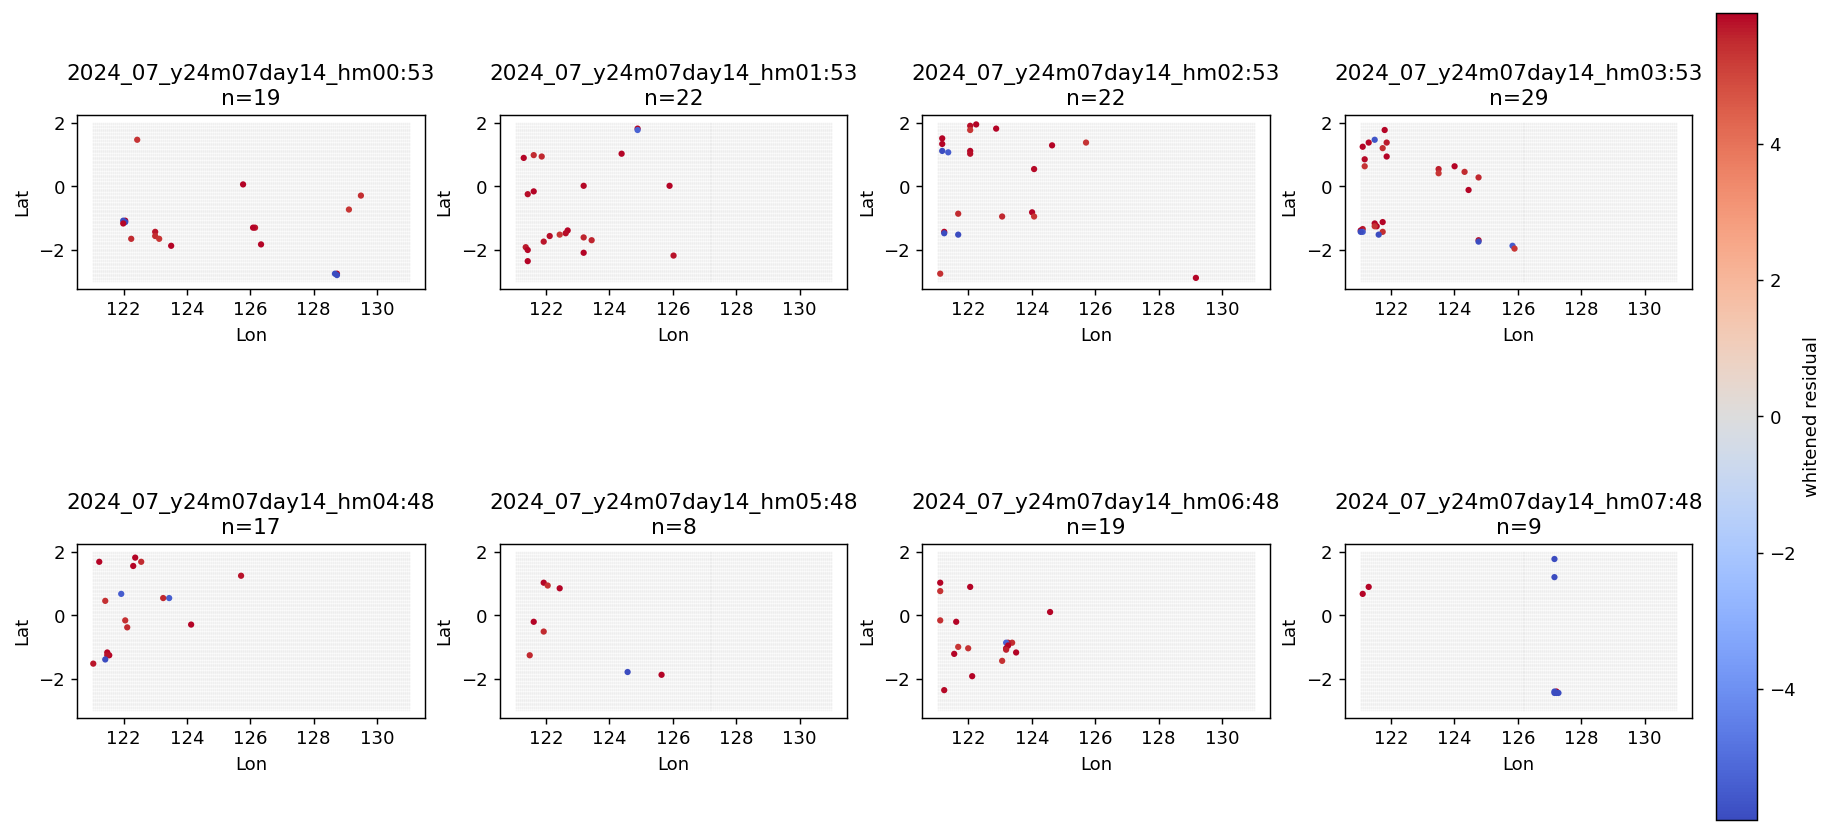

In [12]:
vmax = float(np.nanquantile(np.abs(W_focus[np.isfinite(W_focus)]), 0.9995))
fig, axes = plt.subplots(2, 4, figsize=(14, 6.6), constrained_layout=True)
for ax, key, t_idx in zip(axes.ravel(), selected_keys, range(n_time)):
    vals = np.full(n_grid, np.nan)
    vals[out_mask[t_idx]] = W_focus[t_idx, out_mask[t_idx]]
    ax.scatter(base_grid_coords_np[:, 1], base_grid_coords_np[:, 0], s=1.0, color='lightgray', alpha=0.25, linewidths=0)
    sc = ax.scatter(base_grid_coords_np[:, 1], base_grid_coords_np[:, 0], c=vals, s=12, cmap='coolwarm', vmin=-vmax, vmax=vmax, linewidths=0)
    ax.set_title(f'{key}\n' + f'n={int(out_mask[t_idx].sum())}')
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
    ax.set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.015, label='whitened residual')
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_outlier_locations_by_hour.png')
plt.show()


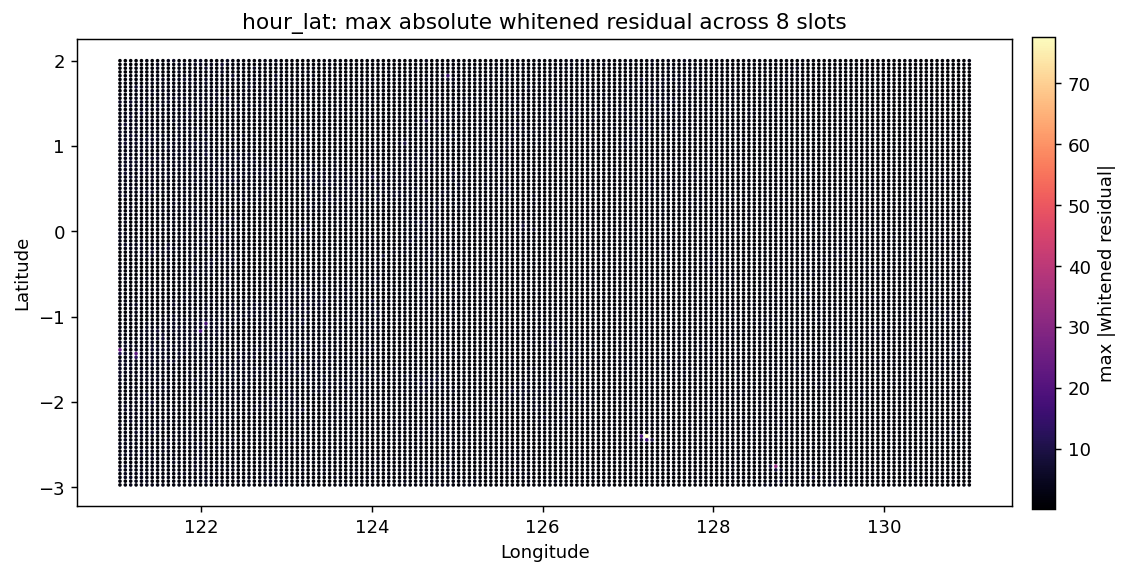

In [13]:
top_abs = np.full(n_grid, np.nan)
for j in range(n_grid):
    vals = np.abs(W_focus[:, j])
    if np.isfinite(vals).any():
        top_abs[j] = np.nanmax(vals)

fig, ax = plt.subplots(figsize=(8.8, 4.4))
base = ax.scatter(base_grid_coords_np[:, 1], base_grid_coords_np[:, 0], c=top_abs, s=4, cmap='magma', linewidths=0)
ax.set_title(f'{FOCUS_DESIGN}: max absolute whitened residual across 8 slots')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='box')
fig.colorbar(base, ax=ax, fraction=0.035, pad=0.02, label='max |whitened residual|')
fig.tight_layout()
fig.savefig(OUT_DIR / f'{OUT_PREFIX}_{FOCUS_DESIGN}_max_abs_map.png')
plt.show()


In [14]:
# Compact readout for quick interpretation.
print('Focus design:', FOCUS_DESIGN)
print('Threshold:', thr_focus)
print('Number of top outliers:', len(outlier_df))
print()
print('Hour counts:')
print(round_numeric_df(hour_counts).to_string(index=False))
if not cluster_df.empty:
    print()
    print('Largest clusters:')
    print(round_numeric_df(cluster_df.head(12)).to_string(index=False))
print()
print('Saved outputs under:', OUT_DIR)


Focus design: hour_lat
Threshold: 5.277864919529237
Number of top outliers: 145

Hour counts:
 time_idx                    time_key  n_outliers  max_abs  mean_abs  n_positive  n_negative
        0 2024_07_y24m07day14_hm00:53          19  32.7598    8.8607          15           4
        1 2024_07_y24m07day14_hm01:53          22  15.1705    6.4292          21           1
        2 2024_07_y24m07day14_hm02:53          22  21.9875    7.0894          18           4
        3 2024_07_y24m07day14_hm03:53          29  24.3442    6.7964          23           6
        4 2024_07_y24m07day14_hm04:48          17   7.5693    5.9294          14           3
        5 2024_07_y24m07day14_hm05:48           8   6.6659    5.9204           7           1
        6 2024_07_y24m07day14_hm06:48          19   7.4877    5.8846          18           1
        7 2024_07_y24m07day14_hm07:48           9  77.6565   16.9808           3           6

Largest clusters:
  design  time_idx                    time_key  cl